# Set Working Directory

In [1]:
# %cd /home/admin_rech/repos/anomalib/examples/01_getting_started/
import os
from pathlib import Path
from dotenv import load_dotenv # For loading environment variables from a .env file
load_dotenv()
from git.repo import Repo
current_directory = Path.cwd()
print(f"Current directory: {current_directory}")
if current_directory.name == "01_getting_started":
    # On the assumption that, the notebook is located in
    #   ~/anomalib/examples/notebooks/01_getting_started/
    root_directory = current_directory.parent.parent
elif current_directory.name == "anomalib":
    # This means that the notebook is run from the main anomalib directory.
    root_directory = current_directory
else:
    # Otherwise, we'll need to clone the anomalib repo to the `current_directory`
    repo = Repo.clone_from(
        url="https://github.com/open-edge-platform/anomalib.git",
        to_path=current_directory,
    )
    root_directory = current_directory / "anomalib"

os.chdir(root_directory)
print(f"Current working directory: {os.getcwd()}")

Current directory: /home/admin_rech/repos/anomalib
Current working directory: /home/admin_rech/repos/anomalib


# Imports

In [2]:
import numpy as np
import wandb
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt
from PIL import Image
from anomalib.data import MVTecAD   
from anomalib.metrics import AUPRO, AUROC, F1Score, AUPRO, AUPIMO, AUPR, Evaluator
# from anomalib.pipelines import Benchmark
from torchvision.transforms.v2.functional import to_pil_image
from anomalib.data import Folder
from anomalib.engine import Engine
from anomalib.models import Patchcore, AnomalyDINO
from anomalib.utils.post_processing import superimpose_anomaly_map
from anomalib.loggers import AnomalibWandbLogger


/home/admin_rech/micromamba/envs/anomalib/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Data Module

In [3]:
# For custom datasets
Folder??


Init signature:
Folder(
    name: str,
    normal_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path],
    root: str | pathlib.Path | None = None,
    abnormal_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path] | None = None,
    normal_test_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path] | None = None,
    mask_dir: str | pathlib.Path | collections.abc.Sequence[str | pathlib.Path] | None = None,
    normal_split_ratio: float = 0.2,
    extensions: tuple[str] | None = None,
    train_batch_size: int = 32,
    eval_batch_size: int = 32,
    num_workers: int = 8,
    train_augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    val_augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    test_augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    augmentations: torchvision.transforms.v2._transform.Transform | None = None,
    test_split_mode: anomalib.d

In [ ]:
dataset_root = root_directory / "datasets" / "MVTecAD"
datamodule = MVTecAD(
    root=dataset_root,
    category="bottle",
    train_batch_size=32,
    eval_batch_size=32,
)

In [4]:
dataset_root = root_directory / "datasets" / "quai_raw"
folder_datamodule = Folder(
    name="quai_raw",
    root=dataset_root,
    normal_dir="good",
    abnormal_dir="defect",
    mask_dir=dataset_root / "masks" / "defect",
)
folder_datamodule.setup() # For loading the dataset, making the splits and preparing the dataloaders

In [5]:
# Train images
data = next(iter(folder_datamodule.train_data))
print(data.image.shape)

torch.Size([3, 512, 512])


In [6]:
# Test images
data = next(iter(folder_datamodule.test_data))
print(data.image.shape, data.gt_mask.shape)

torch.Size([3, 512, 512]) torch.Size([512, 512])


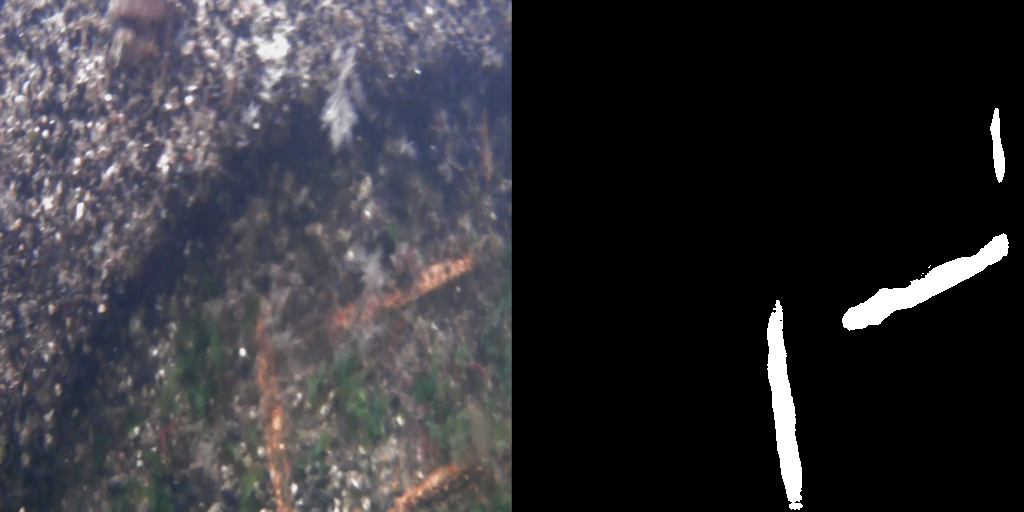

In [7]:
img = to_pil_image(data.image.clone())
msk = to_pil_image(data.gt_mask.int() * 255).convert("RGB")

Image.fromarray(np.hstack((np.array(img), np.array(msk))))

# Logger

In [ ]:
wandb.login(key=os.getenv("WANDB_API_KEY"))

In [ ]:

wandb_logger = AnomalibWandbLogger(
    project="anomaly_quai",
    name="patchcore_first_run",
    entity="jorawar-singh-dham-universit-de-montr-al",
    save_dir=root_directory / "logs", 
    notes="This is a test run for the Quai dataset using PatchCore model.",
    log_model=True,
    job_type="training",)


# Callbacks

In [8]:
callbacks = [
    ModelCheckpoint(
        mode="max",
        monitor="pixel_AUROC",
    ),
    EarlyStopping(
        monitor="pixel_AUROC",
        mode="max",
        patience=3,
    ),
]

# Metrics

In [13]:
# val metrics (needed for early stopping)
image_auroc = AUROC(fields=["pred_score", "gt_label"], prefix="image_")
pixel_auroc = AUROC(fields=["anomaly_map", "gt_mask"], prefix="pixel_")
val_metrics = [image_auroc, pixel_auroc]

# test_metrics
image_auroc = AUROC(fields=["pred_score", "gt_label"], prefix="image_")
image_f1score = F1Score(fields=["pred_label", "gt_label"], prefix="image_")
image_aupr = AUPR(fields=["pred_score", "gt_label"], prefix="image_")
pixel_auroc = AUROC(fields=["anomaly_map", "gt_mask"], prefix="pixel_")
pixel_f1score = F1Score(fields=["pred_mask", "gt_mask"], prefix="pixel_")
pixel_aupro = AUPRO(fields=["anomaly_map", "gt_mask"], prefix="pixel_")
pixel_aupimo = AUPIMO(fields=["anomaly_map", "gt_mask"], prefix="pixel_")
test_metrics = [image_auroc, image_f1score, image_aupr, pixel_auroc, pixel_f1score, pixel_aupro, pixel_aupimo]
normal_evaluator = Evaluator(val_metrics=val_metrics, test_metrics=test_metrics)
patchcore_evaluator = Evaluator(test_metrics=test_metrics)

Metric `AUPIMO` will save all targets and predictions in buffer. For large datasets this may lead to large memory footprint.


# Model

In [10]:
Patchcore??

Init signature:
Patchcore(
    backbone: str = 'wide_resnet50_2',
    layers: collections.abc.Sequence[str] = ('layer2', 'layer3'),
    pre_trained: bool = True,
    coreset_sampling_ratio: float = 0.1,
    num_neighbors: int = 9,
    precision: str | anomalib.PrecisionType = <PrecisionType.FLOAT32: 'float32'>,
    pre_processor: torch.nn.modules.module.Module | bool = True,
    post_processor: torch.nn.modules.module.Module | bool = True,
    evaluator: anomalib.metrics.evaluator.Evaluator | bool = True,
    visualizer: anomalib.visualization.base.Visualizer | bool = True,
) -> None
Source:        
class Patchcore(MemoryBankMixin, AnomalibModule):
    """PatchCore Lightning Module for anomaly detection.

    This class implements the PatchCore algorithm which uses a memory bank of patch
    features for anomaly detection. Features are extracted from a pretrained CNN
    backbone and stored in a memory bank. Anomalies are detected by comparing test
    image patches with the stored fea

In [ ]:
model = Patchcore(evaluator=patchcore_evaluator)

In [12]:
print(model.evaluator)

Evaluator(
  (val_metrics): ModuleList()
  (test_metrics): ModuleList(
    (0): AUROC()
    (1): F1Score()
    (2): AUROC()
    (3): F1Score()
  )
)


# Setup Engine

In [ ]:
kwargs = {"log_every_n_steps": 3}

engine = Engine(
    callbacks=callbacks,
    accelerator="auto",
    logger=None,  # Logger is set here
    **kwargs,
)

# Training

In [ ]:
engine.fit(datamodule=datamodule, model=model)

# Test

In [ ]:
engine.test(datamodule=datamodule, model=model)